# Labor Market Intelligence — integrated notebook

**Question:** Which skills does Vietnam's 2026 IT/Data job market ask for, and which seniority levels and skills go with higher pay?

| | Question | Method |
|---|---|---|
| Q1 | Which skills are required together? | Apriori, time-based train/test split |
| Q2 | How many job families emerge from skill sets? | Hierarchical clustering (Jaccard, weighted) + purity |
| Q3 | Which seniority/skills/locations go with higher pay? | Decision tree (nested CV) + bias analysis |

Each model is also compared with alternative methods under the same evaluation (section 7).

The notebook calls the exact functions in `src/models/` and **checks that results match the reports** in `reports/`. At the end it writes `reports/key_numbers.json` — every number on the slides comes from that file.

**Required data:** `data/processed/jobs_clean.parquet` and `data/processed/skill_matrix.parquet` (download from Drive, or run `python scripts/run_pipeline.py skills`). Hashes must match `docs/MANIFEST.json`.

The notebook only shows aggregate numbers and **never** prints raw job-description text (ToS commitment, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, group_label, load_data, save_figure, salary_tertiles, skill_share

# load_data() checks the SHA-256 of jobs_clean + skill_matrix against docs/MANIFEST.json and stops on mismatch
jobs, skills = load_data()
print(f"{len(jobs)} jobs, {skills.shape[1]} skills — hashes match docs/MANIFEST.json")

import json
import re

from src.models import apriori as ap
from src.models import classification as clf
from src.models.bias_analysis import compare_groups
from src.models.clustering import calculate_purity_fmeasure
from src.models.features import _sha256, load_and_verify_data

KEY = {}  # numbers for the slides

# Check the hashes of all 4 frozen files
manifest = {e["filename"]: e["sha256"] for e in json.load(open(ROOT / "docs" / "MANIFEST.json"))["files"]}
for name, expected in manifest.items():
    ok = _sha256(ROOT / "data" / "processed" / name) == expected
    print(f"{'✓' if ok else '✗'} {name}")
    assert ok, f"{name} does not match MANIFEST"

688 jobs, 100 skills — hashes match docs/MANIFEST.json
✓ cluster_labels.csv
✓ jobs_clean.parquet
✓ rules_train.csv
✓ skill_matrix.parquet


## 1. Data

In [2]:
raw_jobs, raw_skills = load_and_verify_data()  # original: skill_matrix has 677 rows (jobs with 0 skills dropped)
cluster_labels = pd.read_csv(ROOT / "data" / "processed" / "cluster_labels.csv")
KEY["data"] = {
    "n_jobs": len(jobs),
    "crawl_date": "2026-09-29",
    "n_jobs_with_skills": len(raw_skills),
    "n_skills_in_matrix": raw_skills.shape[1] - 1,
    "n_jobs_clustered": len(cluster_labels),
    "n_jobs_with_salary": int(jobs["has_salary"].sum()),
    "pct_with_salary": round(float(jobs["has_salary"].mean()) * 100, 1),
    "posted_from": f"{jobs['posted_date'].min():%Y-%m-%d}",
    "posted_to": f"{jobs['posted_date'].max():%Y-%m-%d}",
}
# A7 is read from the report generated by scripts/verify_a7.py (independent test set, seed 2026; report in Vietnamese)
a7 = (ROOT / "reports" / "A7_evaluation_seed2026.md").read_text(encoding="utf-8")
KEY["data"]["skill_dict_coverage_a7_pct"] = float(re.search(r"Độ phủ \(micro\): ([\d.]+)%", a7).group(1))
pd.Series(KEY["data"])

n_jobs                               688
crawl_date                    2026-09-29
n_jobs_with_skills                   677
n_skills_in_matrix                   100
n_jobs_clustered                     540
n_jobs_with_salary                   172
pct_with_salary                     25.0
posted_from                   2026-08-10
posted_to                     2026-09-29
skill_dict_coverage_a7_pct          72.6
dtype: object

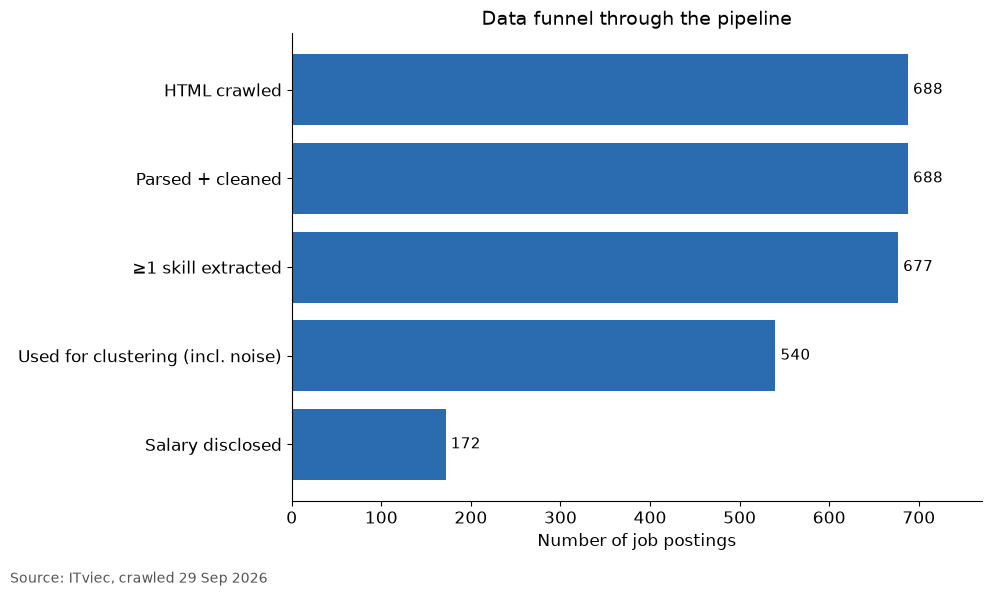

In [3]:
fig = FIGURES["pipeline_funnel"](jobs, skills)

## 2. EDA — highlights

All 14 charts are in `eda_full.ipynb`.

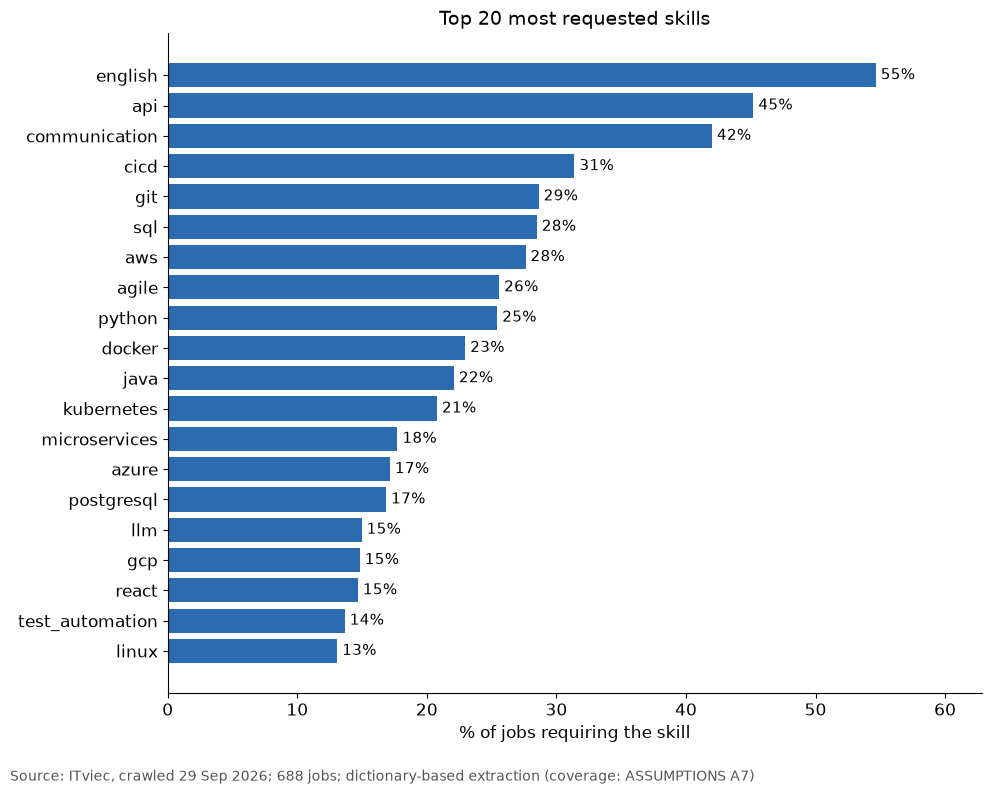

In [4]:
fig = FIGURES["top_skills"](jobs, skills)

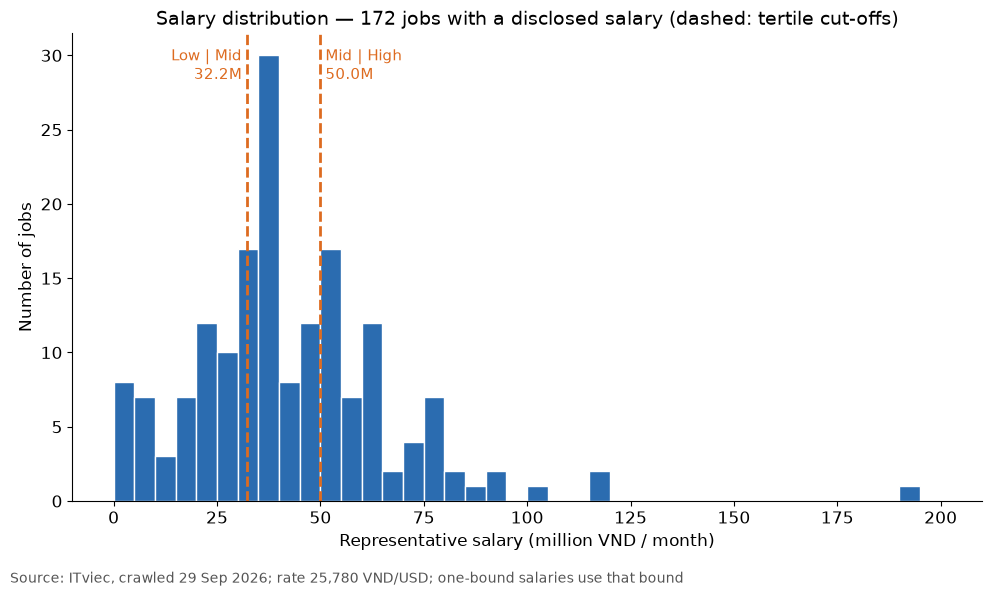

In [5]:
fig = FIGURES["salary_distribution"](jobs, skills)

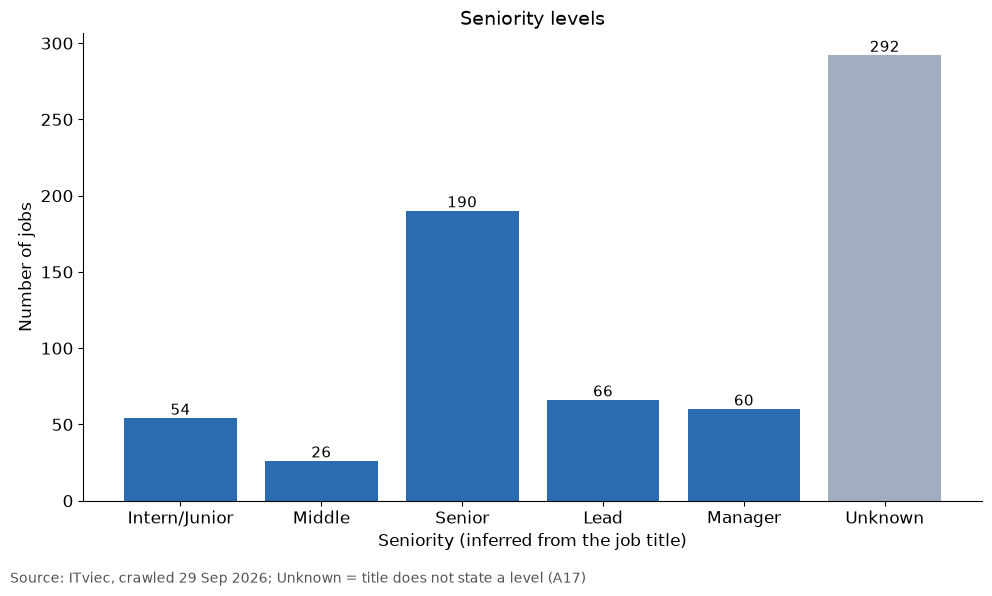

In [6]:
fig = FIGURES["levels"](jobs, skills)

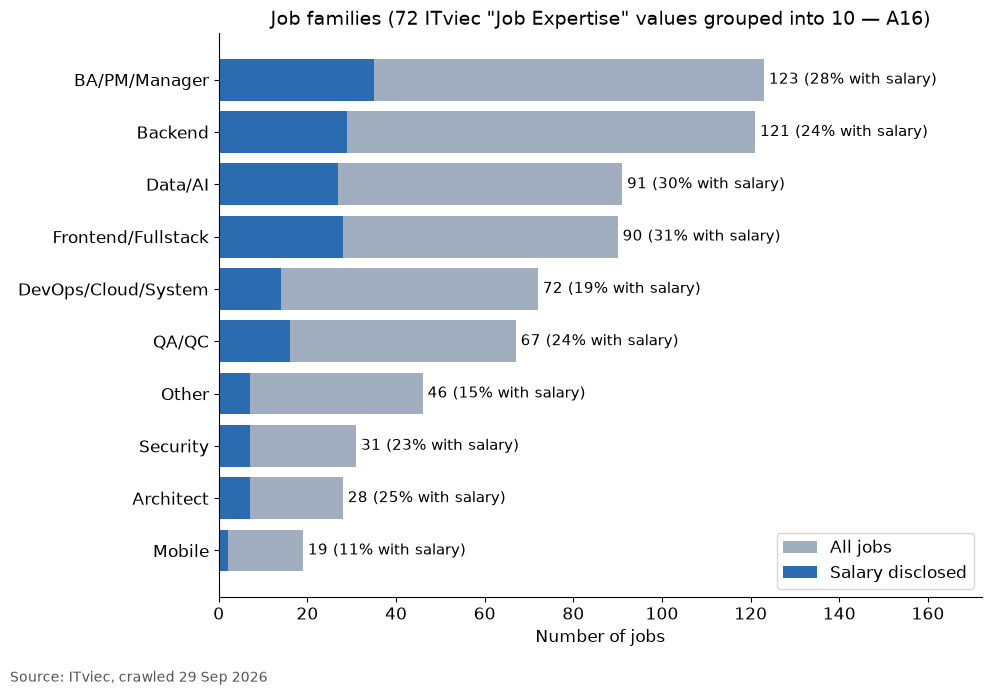

In [7]:
fig = FIGURES["expertise_groups"](jobs, skills)

In [8]:
share = skill_share(skills)
paid = jobs.loc[jobs["has_salary"], "salary_mid"]
KEY["eda"] = {
    "top10_skills_pct": {k: round(float(v) * 100, 1) for k, v in share.head(10).items()},
    "salary_median_million_vnd": round(float(paid.median()), 1),
    "currency_counts": jobs.loc[jobs["has_salary"], "currency_original"].value_counts().to_dict(),
    "pct_level_unknown": round(float((jobs["level_group"] == "Unknown").mean()) * 100, 1),
    "location_counts": {c: int(jobs[c].sum()) for c in ["loc_hcm", "loc_hn", "loc_dn", "loc_other"]},
}
KEY["eda"]

{'top10_skills_pct': {'english': 54.7,
  'api': 45.2,
  'communication': 42.0,
  'cicd': 31.4,
  'git': 28.6,
  'sql': 28.5,
  'aws': 27.6,
  'agile': 25.6,
  'python': 25.4,
  'docker': 23.0},
 'salary_median_million_vnd': 38.7,
 'currency_counts': {'USD': 151, 'VND': 21},
 'pct_level_unknown': 42.4,
 'location_counts': {'loc_hcm': 425,
  'loc_hn': 288,
  'loc_dn': 34,
  'loc_other': 3}}

## 3. Q1 — Skill association rules (Apriori)

The oldest 70% of postings form the train set and the newest 30% the test set (by `posted_date`). Rules are mined on train with lift > 1.2 and confidence ≥ 0.5, then each rule is re-measured on test to see whether it still holds (rule drift).

In [9]:
df = raw_skills.merge(raw_jobs[["job_id", "posted_date"]], on="job_id")
df["posted_date"] = pd.to_datetime(df["posted_date"])
feature_cols = [c for c in df.columns if c not in ("job_id", "posted_date")]
train_part, test_part = ap.chronological_split(df, train_frac=0.7)
train_df, test_df = train_part[feature_cols], test_part[feature_cols]

train_rules, support_counts = ap.run_apriori(train_df, min_supports=[0.03, 0.04, 0.05, 0.06, 0.10],
                                             min_lift=1.2, min_confidence=0.5)
ms_used = float(train_rules["min_support_used"].iloc[0])
print(f"Train {len(train_df)} / Test {len(test_df)} jobs")
print("Rules per min_support:", support_counts, "→ chosen", ms_used, f"({len(train_rules)} rules)")

top = ap.dedup_by_itemset(train_rules, top_n=10)
test_res = ap.evaluate_rules_on_test(top, test_df)
rules_table = pd.DataFrame([{
    "rule": f"{ap.format_itemset(r.antecedents)} → {ap.format_itemset(r.consequents)}",
    "train_conf": round(r.confidence, 3), "train_lift": round(r.lift, 3),
    "test_conf": round(test_res[i]["test_confidence"], 3), "test_lift": round(test_res[i]["test_lift"], 3),
} for i, r in top.iterrows()])
rules_table

Train 473 / Test 204 jobs
Rules per min_support: {0.03: 3227, 0.04: 1382, 0.05: 589, 0.06: 253, 0.1: 43} → chosen 0.1 (43 rules)


,rule,train_conf,train_lift,test_conf,test_lift
0,spring → java,1.000,4.683,1.000,4.000
1,kubernetes → docker,0.656,3.200,0.723,2.419
2,gcp → aws,0.812,2.999,0.939,3.091
3,microservices → kubernetes,0.585,2.884,0.400,1.736
4,azure → aws,0.744,2.749,0.778,2.559
5,"api, docker → cicd",0.800,2.540,0.614,1.868
6,"aws, git → cicd",0.787,2.498,0.966,2.940
7,docker → cicd,0.742,2.356,0.656,1.997
8,git → cicd,0.690,2.190,0.691,2.104
9,"api, git → cicd",0.687,2.180,0.667,2.030


In [10]:
# Check: matches reports/rules_eval.md (generated by src/models/apriori.py; report is in Vietnamese)
rules_md = (ROOT / "reports" / "rules_eval.md").read_text(encoding="utf-8")
assert f"Train: {len(train_df)} bản ghi" in rules_md and f"tìm được {len(train_rules)} luật" in rules_md
first = top.iloc[0]
assert f"| {ap.format_itemset(first.antecedents)} | {ap.format_itemset(first.consequents)} | {first.support:.3f} |" in rules_md
print("✓ matches reports/rules_eval.md")

hold = sum(1 for i in top.index if test_res[i]["test_lift"] > 1.2 and test_res[i]["test_confidence"] >= 0.5)
KEY["q1_rules"] = {
    "n_train": len(train_df), "n_test": len(test_df), "min_support": ms_used, "n_rules": len(train_rules),
    "top_rules_hold_on_test": f"{hold}/{len(top)}",
    "top_rules": rules_table.head(5).to_dict("records"),
}
print(f"{hold}/{len(top)} top rules still have lift > 1.2 and confidence ≥ 0.5 on test")

✓ matches reports/rules_eval.md
9/10 top rules still have lift > 1.2 and confidence ≥ 0.5 on test


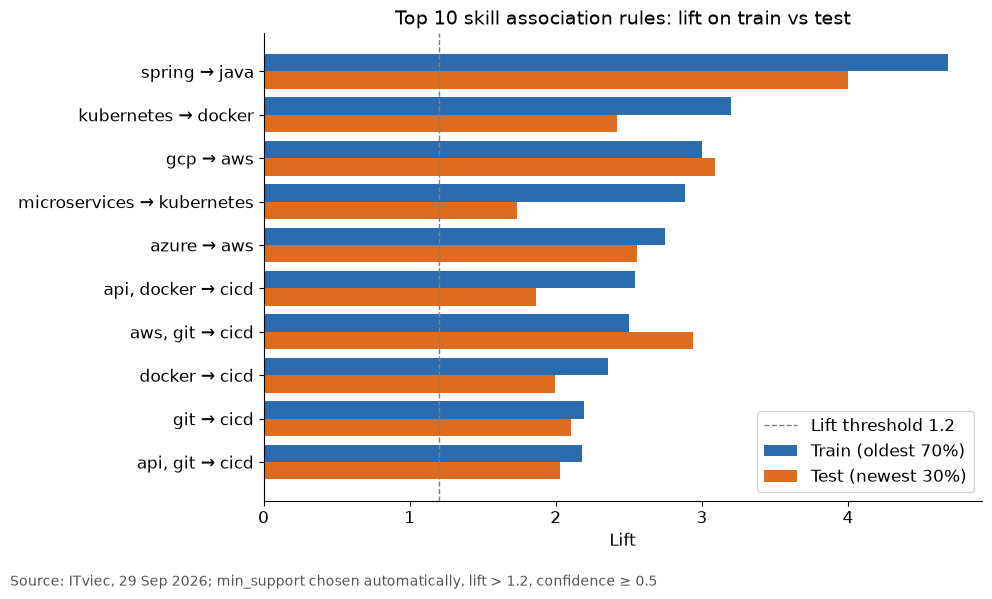

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rules_table))
ax.barh(y - 0.2, rules_table["train_lift"], height=0.4, color="#2b6cb0", label="Train (oldest 70%)")
ax.barh(y + 0.2, rules_table["test_lift"], height=0.4, color="#dd6b20", label="Test (newest 30%)")
ax.axvline(1.2, color="grey", linestyle="--", linewidth=1, label="Lift threshold 1.2")
ax.set_yticks(y, rules_table["rule"])
ax.invert_yaxis()
ax.set_xlabel("Lift")
ax.set_title("Top 10 skill association rules: lift on train vs test")
ax.legend(loc="lower right")
fig.text(0.01, 0.01, "Source: ITviec, 29 Sep 2026; min_support chosen automatically, lift > 1.2, confidence ≥ 0.5",
         fontsize=10, color="#555555")
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(ROOT / "reports" / "figures" / "model_rules_train_test.png", dpi=150)

**Reading:** most top rules still hold on the test set (count printed above). Note the data is a snapshot of open jobs, so train and test differ in *posting age*, not in long-term market change.

## 4. Q2 — Clustering jobs by skills

Hierarchical clustering with Jaccard distance and weighted linkage (`src/models/clustering.py`). Clusters with fewer than 15 jobs are treated as **noise** (label -1); k is valid with ≥ 3 real clusters and ≤ 5% noise, and the valid k with the highest silhouette is chosen (DECISIONS 04/10). Evaluated by purity against 10 job families grouped from "Job Expertise" (A16), on non-noise jobs.

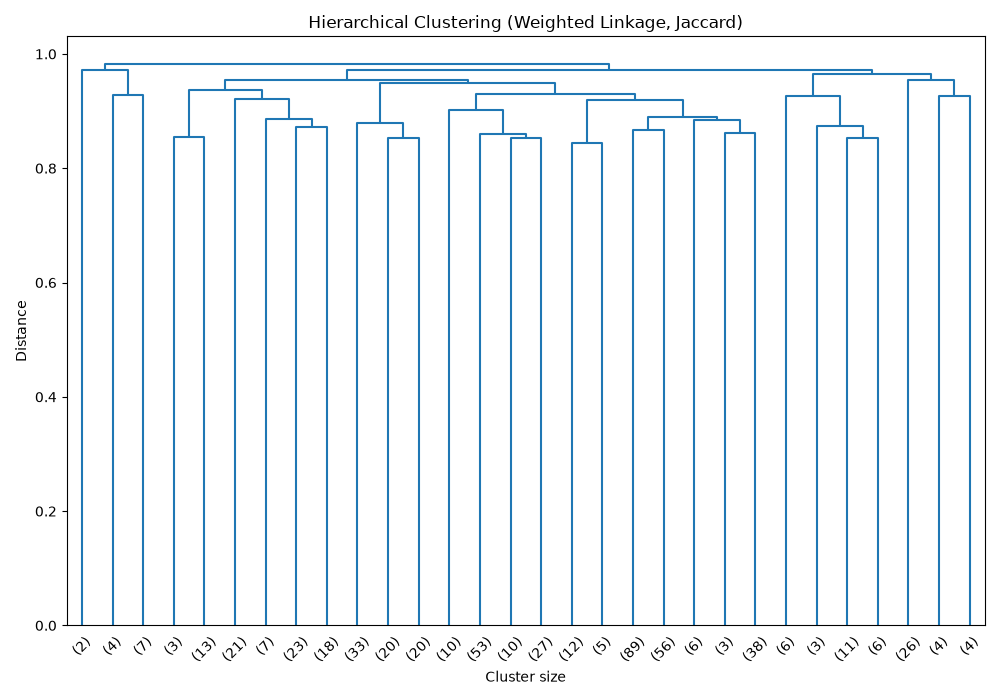

In [12]:
display(Image(filename=str(ROOT / "reports" / "figures" / "dendrogram.png"), width=800))

In [13]:
from src.models.clustering import NOISE_LABEL
real = cluster_labels[cluster_labels["cluster"] != NOISE_LABEL]
n_noise = int((cluster_labels["cluster"] == NOISE_LABEL).sum())
merged = real.merge(jobs[["expertise_group"]], left_on="job_id", right_index=True)
crosstab = pd.crosstab(merged["cluster"], merged["expertise_group"])
purity, baseline_purity, f_measure = calculate_purity_fmeasure(crosstab)
sizes = real["cluster"].value_counts().sort_index()

purity_md = (ROOT / "reports" / "purity_report.md").read_text(encoding="utf-8")
assert f"**Purity:** {purity:.4f}" in purity_md, "Does not match reports/purity_report.md"
sil = float(purity_md.split("silhouette = ")[1].split()[0])
k_cut = int(re.search(r"\*\*K đã chọn:\*\* (\d+)", purity_md).group(1))  # report is in Vietnamese
print("✓ matches reports/purity_report.md")
print(f"k = {k_cut} → {len(sizes)} real clusters {sizes.to_dict()} + {n_noise} noise jobs "
      f"({n_noise / len(cluster_labels):.1%}); silhouette {sil:.3f}")
print(f"Purity {purity:.3f} (baseline {baseline_purity:.3f}), F-measure {f_measure:.3f}")
KEY["q2_clustering"] = {
    "k_cut": k_cut, "n_real_clusters": int(len(sizes)), "n_noise_jobs": n_noise,
    "cluster_sizes": {int(k): int(v) for k, v in sizes.items()},
    "silhouette": round(sil, 3), "purity": round(float(purity), 3),
    "baseline_purity": round(float(baseline_purity), 3), "f_measure": round(float(f_measure), 3),
    "pct_jobs_in_largest_cluster": round(float(sizes.max() / sizes.sum()) * 100, 1),
}
crosstab.rename(columns=group_label)

✓ matches reports/purity_report.md
k = 8 → 5 real clusters {1: 309, 2: 85, 3: 73, 4: 26, 5: 26} + 21 noise jobs (3.9%); silhouette 0.066
Purity 0.322 (baseline 0.214), F-measure 0.343


expertise_group,Architect,BA/PM/Manager,Backend,Data/AI,DevOps/Cloud/System,Frontend/Fullstack,Other,Mobile,QA/QC,Security
cluster,,,,,,,,,,
1,15,12,84,25,42,73,4,13,30,11
2,2,3,7,32,15,2,17,1,1,5
3,3,24,17,14,2,7,1,1,2,2
4,4,5,3,9,4,0,0,0,0,1
5,1,3,0,0,0,2,1,1,18,0


✓ top 5 skills of each cluster match reports/purity_report.md


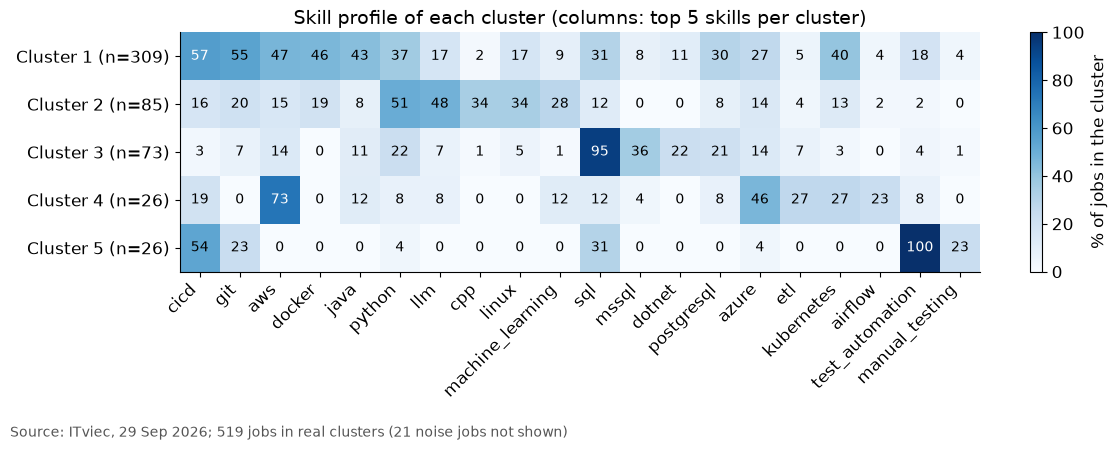

In [14]:
# Skill profile per cluster — uses exactly the skills kept by clustering.py
# (drops soft/management skills, skills in > 40% of jobs or < 10 jobs); columns = union of each cluster's top 5
from src.models.clustering import FREQUENT_SKILL_RATIO, MANUAL_DROPS, RARE_SKILL_MIN
sm = raw_skills.set_index("job_id").sort_index(axis=1)  # same column order as clustering.py
kept = [s for s in sm.columns if sm[s].mean() <= FREQUENT_SKILL_RATIO and sm[s].sum() >= RARE_SKILL_MIN
        and s not in MANUAL_DROPS]
in_clusters = sm.loc[real["job_id"], kept]
by_cluster = in_clusters.groupby(real["cluster"].values).mean()
cols = []
for c in by_cluster.index:
    # same stable sort as clustering.py (ties broken by skill name)
    top5 = by_cluster.loc[c].sort_values(ascending=False, kind="mergesort").head(5)
    line = ", ".join(f"{s} ({v:.0%})" for s, v in top5.items())
    assert f"**Cụm {c}** ({sizes[c]} tin): {line}" in purity_md, f"Top 5 of cluster {c} does not match purity_report.md"
    cols += [s for s in top5.index if s not in cols]
print("✓ top 5 skills of each cluster match reports/purity_report.md")
profile = by_cluster[cols] * 100

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(profile.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(profile)), [f"Cluster {c} (n={sizes[c]})" for c in profile.index])
for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        v = profile.iat[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=10, color="white" if v > 55 else "black")
fig.colorbar(im, ax=ax, label="% of jobs in the cluster")
ax.set_title("Skill profile of each cluster (columns: top 5 skills per cluster)")
fig.text(0.01, 0.01, f"Source: ITviec, 29 Sep 2026; {len(real)} jobs in real clusters ({n_noise} noise jobs not shown)",
         fontsize=10, color="#555555")
fig.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(ROOT / "reports" / "figures" / "model_cluster_profiles.png", dpi=150)

**Reading:** a silhouette close to 0 and one large cluster holding most jobs → skill sets on ITviec **do not separate into clear job families**. The small clusters are more distinctive (see the skill profile). This is a finding, not a bug — see the limitations in `reports/purity_report.md`.

## 5. Q3 — Decision tree for salary bands

Uses only jobs with a disclosed salary; Low/Mid/High labels are tertiles (DECISIONS milestone 2). Features: skills, seniority (inferred from the title), location. Evaluated with nested CV (outer 5 folds, inner 3 folds for tuning), out-of-fold predictions.

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier

X, y, bins = clf.build_dataset(raw_jobs, raw_skills)
oof, folds = clf.nested_cv(X, y)          # a few seconds
y_arr = y.to_numpy(dtype=object)
acc = accuracy_score(y_arr, oof)
ci_low, ci_high = clf.bootstrap_ci(y_arr, oof)
baseline = y.value_counts().max() / len(y)
macro_f1 = f1_score(y_arr, oof, average="macro")
cm = confusion_matrix(y_arr, oof, labels=clf.CLASSES)

report = (ROOT / "reports" / "classification_report.md").read_text(encoding="utf-8")
assert f"**Accuracy:** {acc:.4f}" in report, "Does not match reports/classification_report.md"
print("✓ matches reports/classification_report.md")
print(f"{len(X)} jobs, {X.shape[1]} features; classes {y.value_counts().reindex(clf.CLASSES).to_dict()}")
print(f"Tertile cut-offs: {bins[1]:.1f} / {bins[2]:.1f} million VND / month")
print(f"OOF accuracy {acc:.3f} (95% CI {ci_low:.3f}–{ci_high:.3f}) | baseline {baseline:.3f} | macro-F1 {macro_f1:.3f}")
folds

✓ matches reports/classification_report.md
172 jobs, 81 features; classes {'Low': 60, 'Mid': 55, 'High': 57}
Tertile cut-offs: 32.2 / 50.0 million VND / month
OOF accuracy 0.517 (95% CI 0.442–0.593) | baseline 0.349 | macro-F1 0.520


,fold,max_depth,min_samples_leaf,inner_cv_accuracy,fold_accuracy
0,1,3,5,0.4957,0.4571
1,2,6,5,0.5327,0.4571
2,3,4,10,0.5072,0.4118
3,4,3,10,0.4348,0.5588
4,5,6,5,0.4783,0.7059


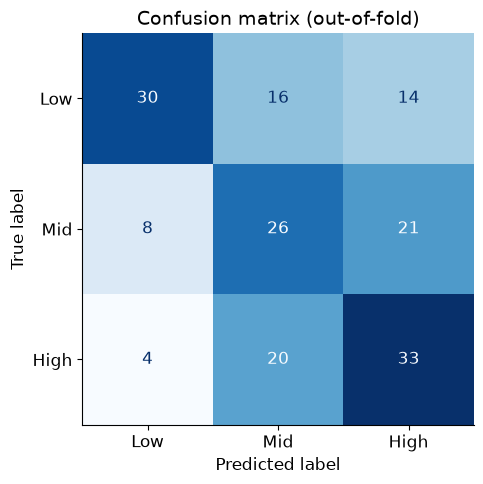

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=clf.CLASSES).plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion matrix (out-of-fold)")
fig.tight_layout()

Recall per class: {'Low': 0.5, 'Mid': 0.473, 'High': 0.579}


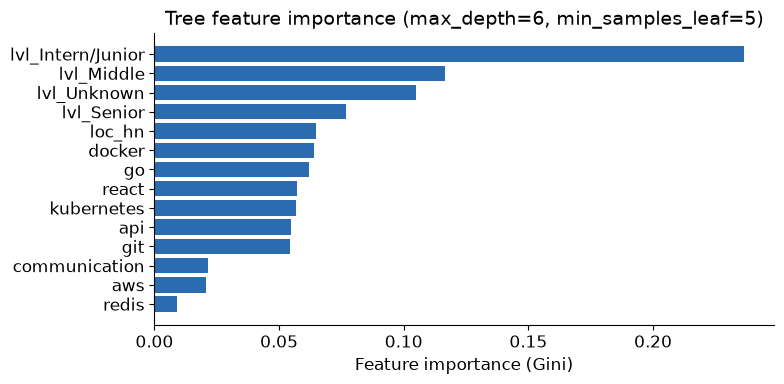

In [17]:
params = clf.choose_final_params(list(zip(folds["max_depth"], folds["min_samples_leaf"])))
model = DecisionTreeClassifier(criterion="gini", max_depth=int(params[0]), min_samples_leaf=int(params[1]),
                               random_state=clf.RANDOM_STATE).fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance[importance > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2b6cb0")
ax.set_xlabel("Feature importance (Gini)")
ax.set_title(f"Tree feature importance (max_depth={params[0]}, min_samples_leaf={params[1]})")
fig.tight_layout()
fig.savefig(ROOT / "reports" / "figures" / "model_feature_importance.png", dpi=150)

recall = {c: round(float(cm[i, i] / cm[i].sum()), 3) for i, c in enumerate(clf.CLASSES)}
KEY["q3_tree"] = {
    "n_jobs": int(len(X)), "n_features": int(X.shape[1]),
    "class_counts": y.value_counts().reindex(clf.CLASSES).to_dict(),
    "tertile_bounds_million_vnd": [round(float(bins[1]), 1), round(float(bins[2]), 1)],
    "accuracy": round(float(acc), 3), "accuracy_ci95": [round(float(ci_low), 3), round(float(ci_high), 3)],
    "baseline": round(float(baseline), 3), "macro_f1": round(float(macro_f1), 3),
    "recall_by_class": recall,
    "final_params": {"max_depth": int(params[0]), "min_samples_leaf": int(params[1])},
    "feature_importance": importance.sort_values(ascending=False).round(3).to_dict(),
}
print("Recall per class:", recall)

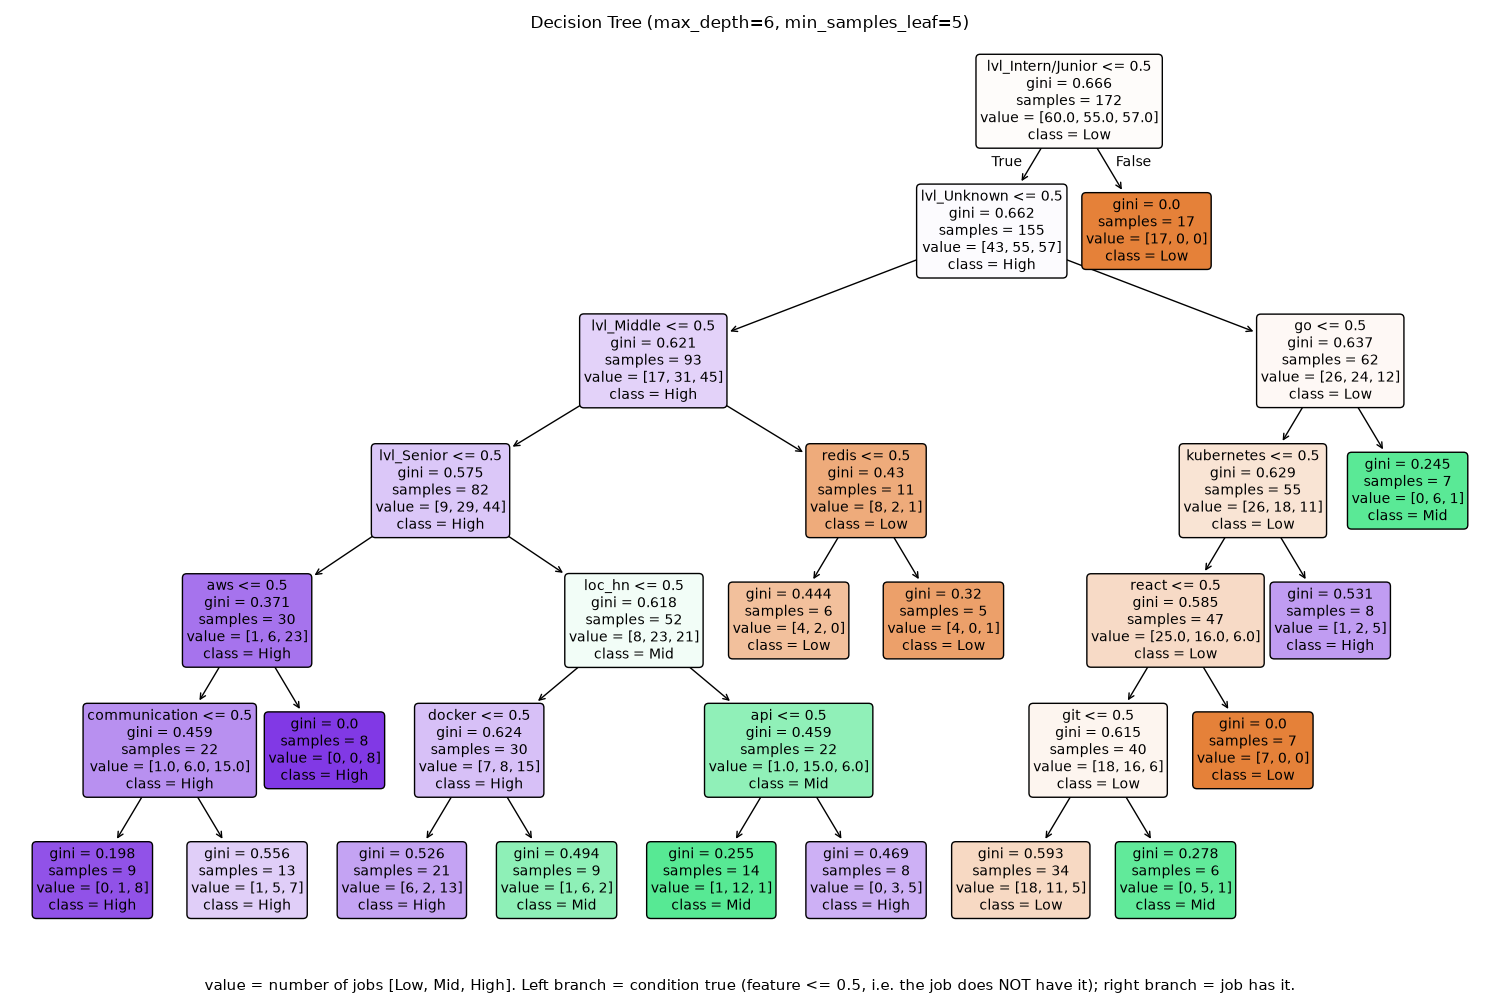

Composition of the Intern/Junior group among salaried jobs (salaries in million VND / month):


,jobs,median,min,max
original level,,,,
Intern,14,4.1,2.3,9.0
Fresher,1,3.6,3.6,3.6
Junior,2,15.7,12.0,19.3


In [18]:
display(Image(filename=str(ROOT / "reports" / "figures" / "tree_viz.png"), width=900))
breakdown = clf.intern_junior_breakdown(raw_jobs)
breakdown.index.name = "original level"
print("Composition of the Intern/Junior group among salaried jobs (salaries in million VND / month):")
breakdown.set_axis(["jobs", "median", "min", "max"], axis=1)

**Reading:** the tree beats the baseline (the CI above excludes it) — there is a real signal. Seniority is the most important feature. ⚠️ The `Intern/Junior` branch is mostly **interns** (allowances) — do not read it as "juniors are paid little". The Mid class is the hardest to separate. Splits on individual skills sit on very few jobs (see `reports/classification_report.md`) — do not read them as "skill X → salary Y".

## 6. Bias: jobs with vs without a salary

The Q3 model only learns from jobs with a salary. Comparing the two groups shows how far the conclusions generalise (details: `reports/bias_analysis.md`).

In [19]:
from scipy.stats import chi2_contingency

has = jobs["has_salary"]
loc_cmp = compare_groups(jobs[["loc_hcm", "loc_hn", "loc_dn", "loc_other"]], has)
skill_cmp = compare_groups(skills, has, min_total=5)
level_p = chi2_contingency(pd.crosstab(jobs["level_group"], has))[1]

bias_md = (ROOT / "reports" / "bias_analysis.md").read_text(encoding="utf-8")
assert f"p-value = {level_p:.4e}" in bias_md, "Does not match reports/bias_analysis.md"
print("✓ matches reports/bias_analysis.md")
n_sig_skills = int((skill_cmp["adj_p_value"] < 0.05).sum())
print(f"Skills with a significant difference (BH adj p < 0.05): {n_sig_skills}/{len(skill_cmp)}")
print(f"Seniority: chi-square p = {level_p:.3f}")
KEY["bias"] = {
    "n_with_salary": int(has.sum()), "n_without_salary": int((~has).sum()),
    "n_skills_tested": int(len(skill_cmp)), "n_skills_significant": n_sig_skills,
    "level_chi2_p": round(float(level_p), 3),
    "location": {c: {"pct_with_salary": round(float(r.iloc[0]) * 100, 1),
                     "pct_without_salary": round(float(r.iloc[1]) * 100, 1),
                     "adj_p": round(float(r["adj_p_value"]), 4)} for c, r in loc_cmp.iterrows()},
}
loc_cmp.set_axis(["% with salary", "% without salary", "difference", "p_value", "adj_p_value"], axis=1).round(4)

✓ matches reports/bias_analysis.md


Skills with a significant difference (BH adj p < 0.05): 0/100
Seniority: chi-square p = 0.060


,% with salary,% without salary,difference,p_value,adj_p_value
loc_hcm,0.4767,0.6647,-0.1880,0.0000,0.0001
loc_hn,0.5174,0.3857,0.1318,0.0032,0.0063
loc_dn,0.0407,0.0523,-0.0116,0.6855,0.9140
loc_other,0.0058,0.0039,0.0019,1.0000,1.0000


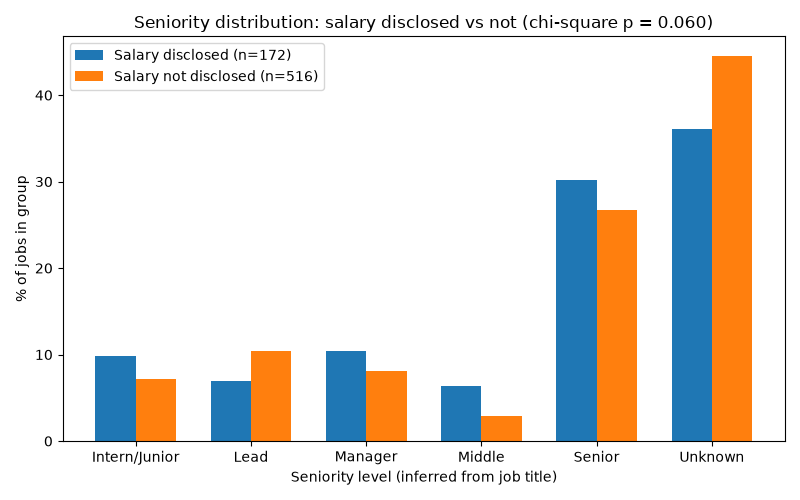

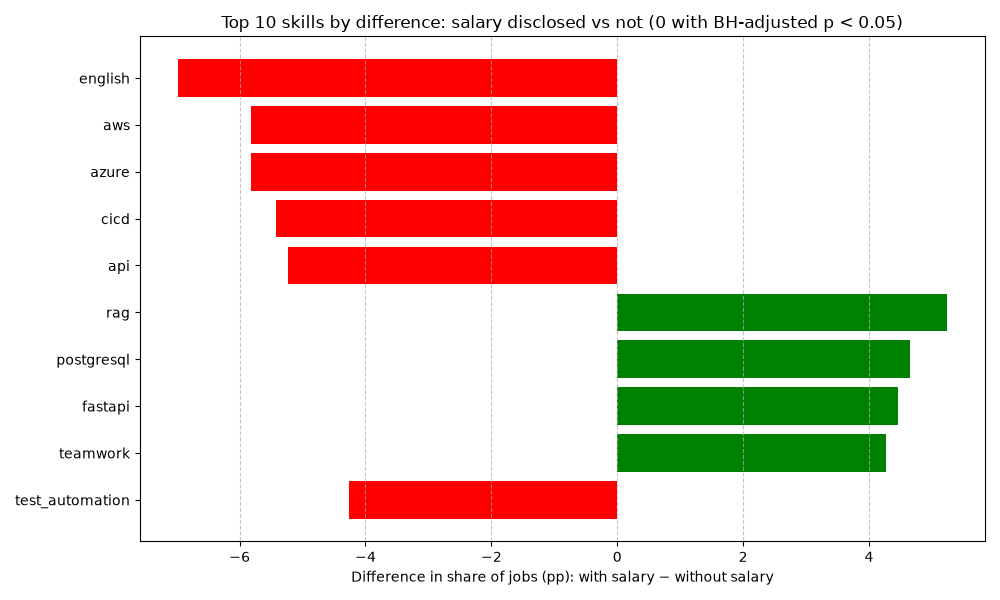

In [20]:
for name in ["bias_levels.png", "bias_skills.png"]:
    display(Image(filename=str(ROOT / "reports" / "figures" / name), width=750))

## 7. Comparison with other methods

Each question's model is compared with alternatives on **the same data, folds and metrics** (`src/models/comparison.py`, `reports/model_comparison.md`; DECISIONS 04/10). The project models are re-run inside the comparison and checked against the results above, so the comparison is like-for-like.

- **Q3:** decision tree vs majority baseline, a seniority-only tree, logistic regression, Bernoulli naive Bayes, k-NN (Jaccard), random forest and gradient boosting — same nested CV; paired bootstrap CI of the accuracy difference vs the tree.
- **Q2:** weighted HAC vs average/complete HAC, K-means and HDBSCAN — same skill matrix and noise rule; plus a subsampling stability check.
- **Q1:** Apriori vs FP-Growth — same rules, runtime compared.

Language-model approaches (e.g. transformer-based skill extraction or salary regression from job text) are discussed as related work only: 172 labelled jobs are far too few to train them, and they are not interpretable.

✓ classifiers match reports/model_comparison.md


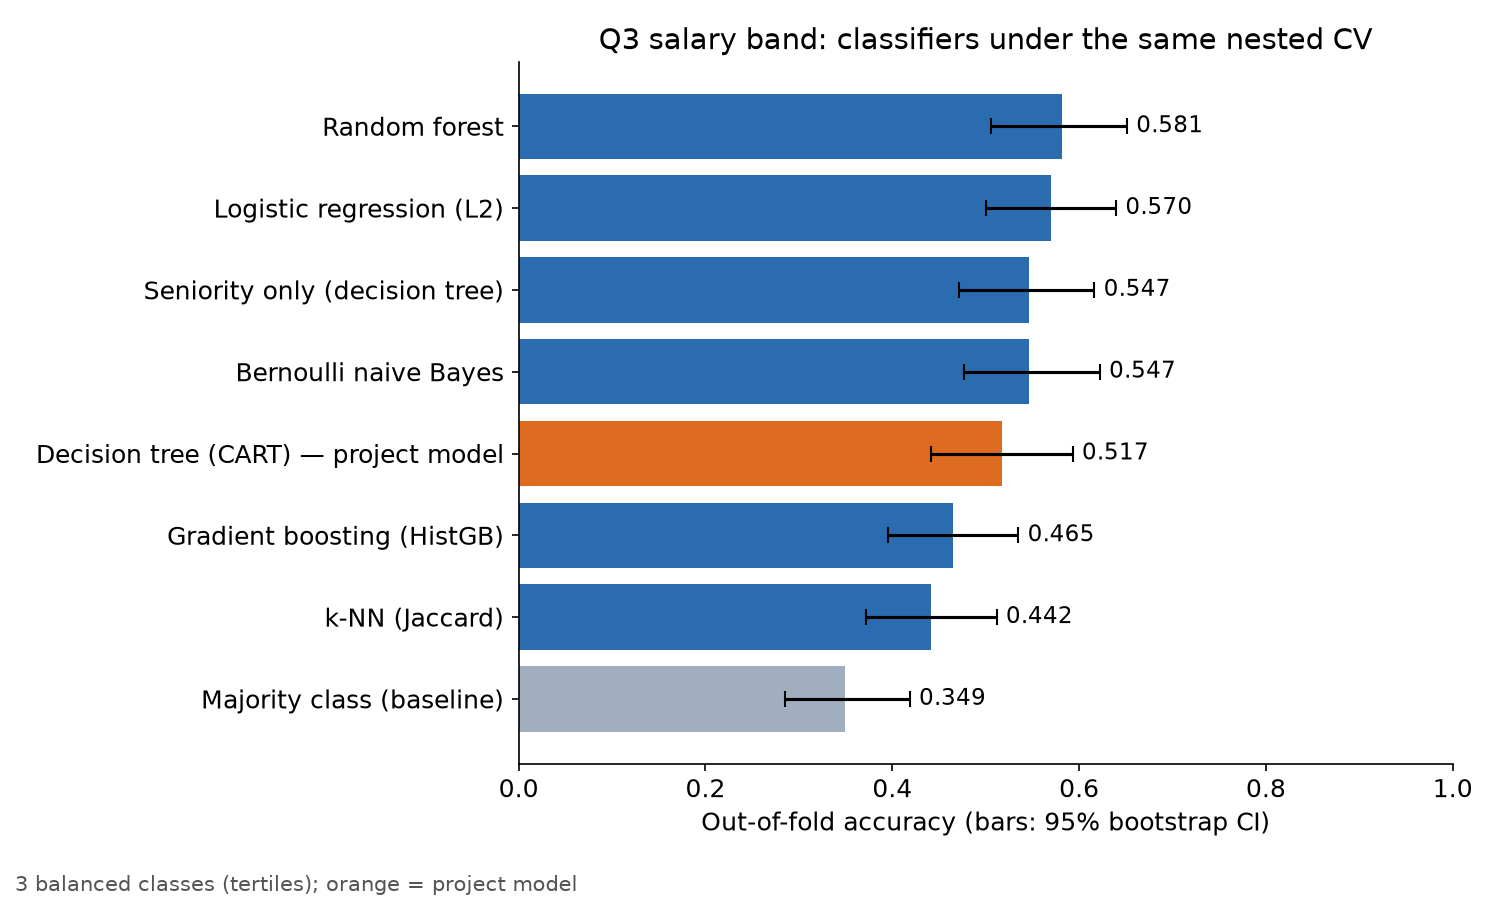

,n_features,accuracy,ci_low,ci_high,macro_f1,recall_Mid,diff_vs_tree_low,diff_vs_tree_high
model,,,,,,,,
Majority class (baseline),81,0.349,0.285,0.419,0.172,0.000,-0.273,-0.064
Seniority only (decision tree),6,0.547,0.471,0.616,0.541,0.509,-0.070,0.122
Decision tree (CART) — project model,81,0.517,0.442,0.593,0.520,0.473,0.000,0.000
Logistic regression (L2),81,0.570,0.500,0.640,0.569,0.491,-0.023,0.134
Bernoulli naive Bayes,81,0.547,0.477,0.622,0.533,0.327,-0.052,0.110
k-NN (Jaccard),81,0.442,0.372,0.512,0.433,0.291,-0.157,0.012
Random forest,81,0.581,0.506,0.651,0.578,0.473,-0.017,0.145
Gradient boosting (HistGB),81,0.465,0.395,0.535,0.463,0.509,-0.145,0.035


In [21]:
from src.models import comparison as cmp

cmp_md = (ROOT / "reports" / "model_comparison.md").read_text(encoding="utf-8")

# Q3 — classifiers (~30 s: random forest and gradient boosting inside nested CV)
clf_table, clf_preds = cmp.compare_classifiers(X, y)
assert (clf_preds["Decision tree (CART) — project model"] == oof).all(), "tree differs from section 5"
for name, r in clf_table.iterrows():
    row = f"| {r['accuracy']:.3f} | {r['ci_low']:.3f} | {r['ci_high']:.3f} | {r['macro_f1']:.3f} |"
    assert f"| {name} |" in cmp_md and row in cmp_md, f"{name} does not match reports/model_comparison.md"
print("✓ classifiers match reports/model_comparison.md")
cmp.plot_classifiers(clf_table, ROOT / "reports" / "figures" / "model_compare_classifiers.png")
display(Image(filename=str(ROOT / "reports" / "figures" / "model_compare_classifiers.png"), width=800))
clf_table[["n_features", "accuracy", "ci_low", "ci_high", "macro_f1", "recall_Mid",
           "diff_vs_tree_low", "diff_vs_tree_high"]].round(3)

✓ clustering methods and stability match reports/model_comparison.md
Stability (ARI, 50 subsamples of 80%): mean 0.345, 5–95% 0.169–0.599


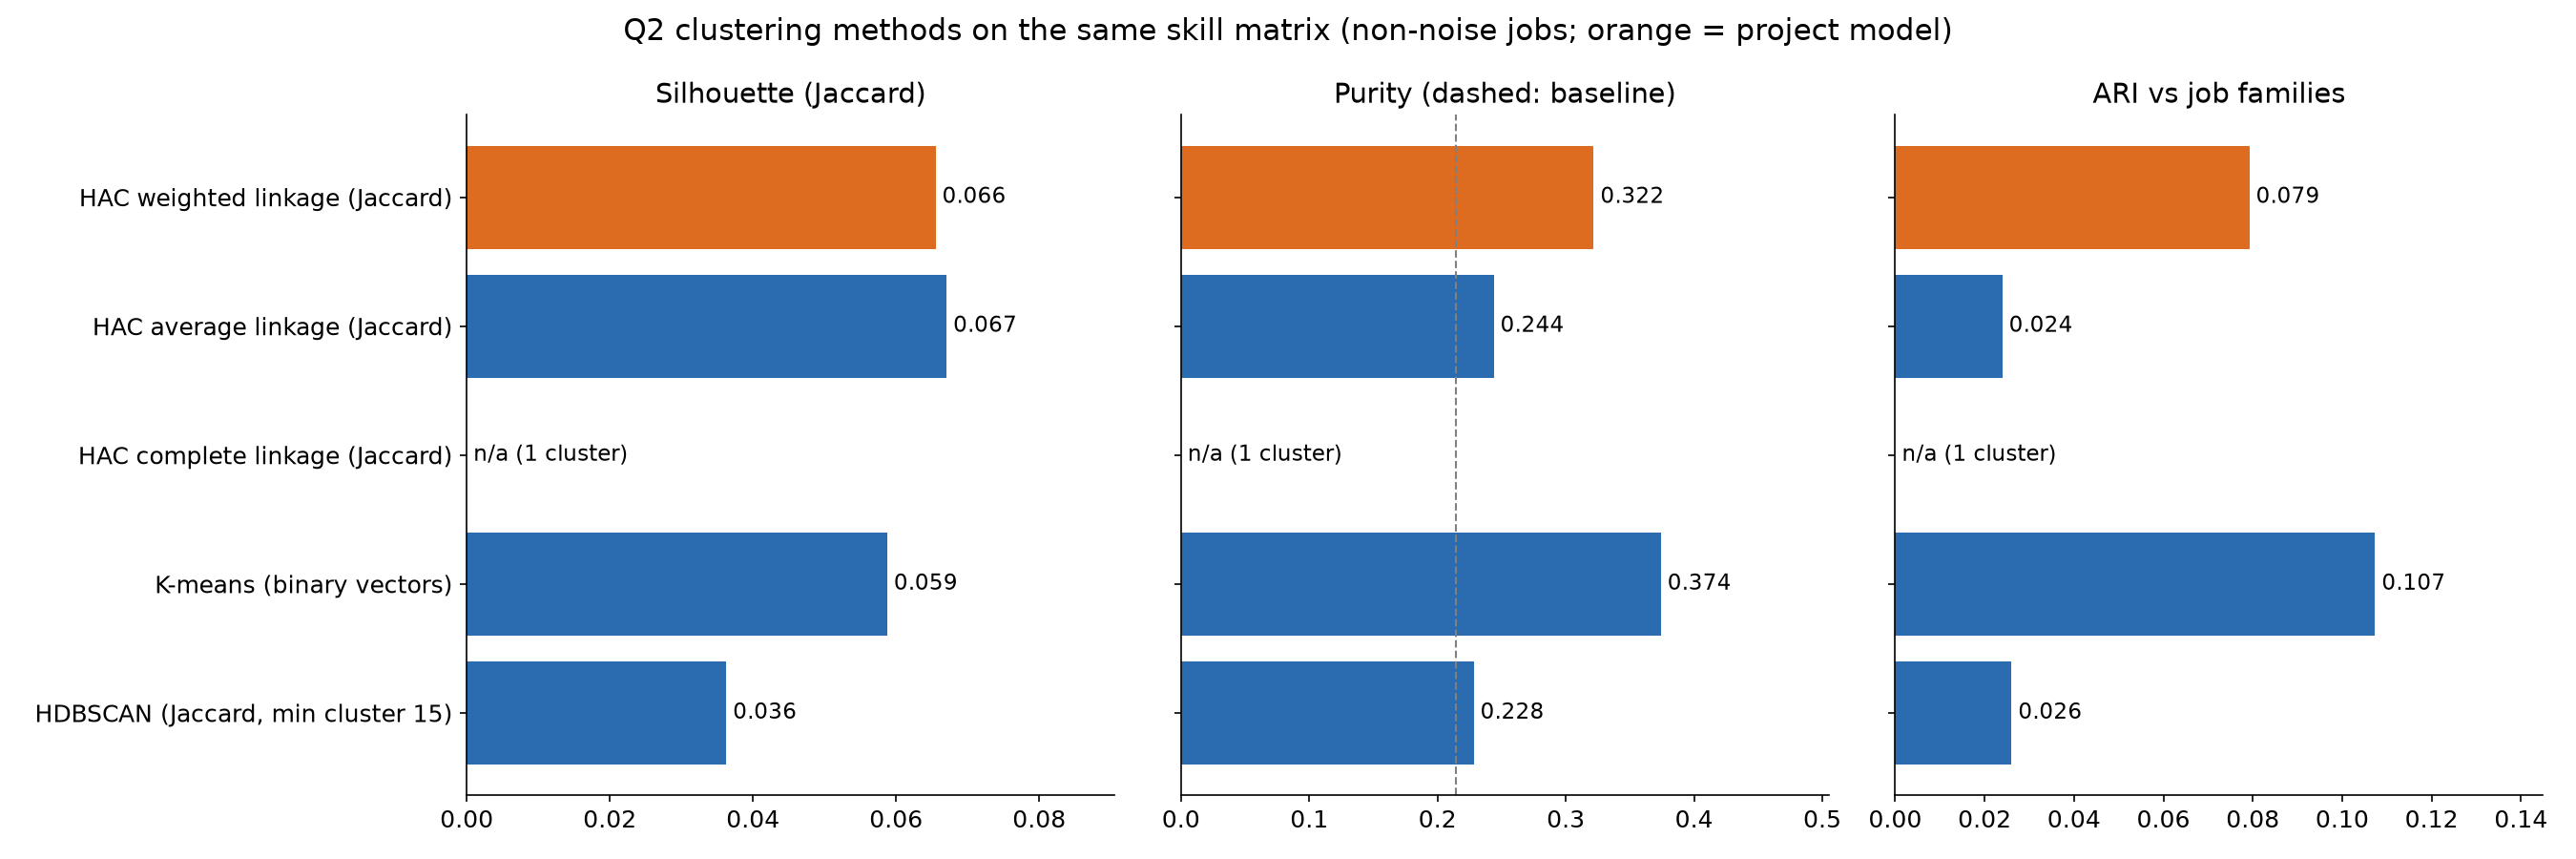

,k,n_real_clusters,noise_share,silhouette,purity,baseline,ari,valid
HAC weighted linkage (Jaccard),8,5,0.038889,0.065508,0.321773,0.213873,0.079213,True
HAC average linkage (Jaccard),6,3,0.035185,0.067053,0.243762,0.214971,0.023949,True
HAC complete linkage (Jaccard),4,1,0.0,NaN,NaN,NaN,NaN,False
K-means (binary vectors),7,7,0.0,0.058751,0.374074,0.209259,0.107349,True
"HDBSCAN (Jaccard, min cluster 15)",None,4,0.237037,0.036266,0.228155,0.220874,0.026028,False


In [22]:
# Q2 — clustering methods + stability of the project model
groups_by_job = jobs["expertise_group"]
clu_table, clu_labels, M, _ = cmp.compare_clustering(raw_skills, groups_by_job)
project_method = "HAC weighted linkage (Jaccard)"
assert (cluster_labels.set_index("job_id").loc[M.index, "cluster"].to_numpy() == clu_labels[project_method]).all()
stability = cmp.clustering_stability(M, int(clu_table.loc[project_method, "k"]))
assert f"mean {stability.mean():.3f}" in cmp_md, "stability does not match reports/model_comparison.md"
for name in clu_table.index:
    assert f"| {name} |" in cmp_md
print("✓ clustering methods and stability match reports/model_comparison.md")
print(f"Stability (ARI, {len(stability)} subsamples of 80%): mean {stability.mean():.3f}, "
      f"5–95% {np.percentile(stability, 5):.3f}–{np.percentile(stability, 95):.3f}")
cmp.plot_clustering(clu_table, ROOT / "reports" / "figures" / "model_compare_clustering.png")
display(Image(filename=str(ROOT / "reports" / "figures" / "model_compare_clustering.png"), width=900))
clu_table[["k", "n_real_clusters", "noise_share", "silhouette", "purity", "baseline", "ari", "valid"]]

In [23]:
# Q2 — is the difference between weighted HAC and K-means real? (paired bootstrap, fixed clusterings)
cl_groups = groups_by_job.reindex(M.index).to_numpy()
cluster_paired = cmp.paired_bootstrap_clustering(clu_labels[project_method], clu_labels["K-means (binary vectors)"],
                                                 cl_groups)
# Stability of every method with a valid k, on the same 50 subsamples of 80%
stabilities = {name: cmp.clustering_stability(M, int(clu_table.loc[name, "k"]), method)
               for name, method in cmp.STABILITY_METHODS.items() if clu_table.loc[name, "valid"]}
for metric, r in cluster_paired.iterrows():
    assert f"| {metric} | {r['a']:.3f} | {r['b']:.3f} | {r['diff']:+.3f} | {r['ci_low']:+.3f} – {r['ci_high']:+.3f} |" in cmp_md
for name, sc in stabilities.items():
    assert f"| {name} | {int(clu_table.loc[name, 'k'])} | {sc.mean():.3f} |" in cmp_md
print("✓ paired bootstrap and stability match reports/model_comparison.md")
display(pd.Series({n: round(float(v.mean()), 3) for n, v in stabilities.items()}, name="stability (mean ARI)"))
cluster_paired.round(3)

✓ paired bootstrap and stability match reports/model_comparison.md


HAC weighted linkage (Jaccard)    0.345
HAC average linkage (Jaccard)     0.454
K-means (binary vectors)          0.630
Name: stability (mean ARI), dtype: float64

,a,b,diff,ci_low,ci_high
metric,,,,,
purity,0.322,0.374,-0.052,-0.108,-0.019
ari,0.079,0.107,-0.028,-0.072,0.002


In [24]:
# Q1 — Apriori vs FP-Growth on the same train set (runtimes depend on the machine; rules must be identical)
rules_cmp = cmp.compare_apriori_fpgrowth(train_df)
assert rules_cmp["same_itemsets"].all() and rules_cmp["same_rules"].all()
print("✓ Apriori and FP-Growth give identical itemsets and rules at every min_support")
cmp.plot_apriori(rules_cmp, ROOT / "reports" / "figures" / "model_compare_apriori_fpgrowth.png")
rules_cmp.round(2)

✓ Apriori and FP-Growth give identical itemsets and rules at every min_support


,min_support,itemsets,rules,same_itemsets,same_rules,apriori_ms,fpgrowth_ms
0,0.03,1565,3227,True,True,9.51,22.08
1,0.04,840,1382,True,True,5.17,14.82
2,0.05,482,589,True,True,3.31,10.89
3,0.06,281,253,True,True,2.51,8.92
4,0.10,75,43,True,True,1.27,4.14


In [25]:
def _r(v):
    return None if pd.isna(v) else round(float(v), 3)

KEY["comparison"] = {
    "q3_classifiers": {n: {"accuracy": _r(r["accuracy"]), "ci95": [_r(r["ci_low"]), _r(r["ci_high"])],
                           "macro_f1": _r(r["macro_f1"]),
                           "diff_vs_tree_ci95": [_r(r["diff_vs_tree_low"]), _r(r["diff_vs_tree_high"])]}
                       for n, r in clf_table.iterrows()},
    "q3_best_model": clf_table["accuracy"].idxmax(),
    "q3_significantly_better_than_tree": [n for n, r in clf_table.iterrows() if r["diff_vs_tree_low"] > 0],
    "q2_methods": {n: {"k": None if pd.isna(r["k"]) else int(r["k"]), "n_real_clusters": int(r["n_real_clusters"]),
                       "noise_share": _r(r["noise_share"]), "silhouette": _r(r["silhouette"]),
                       "purity": _r(r["purity"]), "ari": _r(r["ari"]), "valid": bool(r["valid"])}
                   for n, r in clu_table.iterrows()},
    "q2_stability_ari_mean": _r(stability.mean()),
    "q2_stability_by_method": {n: _r(v.mean()) for n, v in stabilities.items()},
    "q2_hac_minus_kmeans": {m: {"diff": _r(r["diff"]), "ci95": [_r(r["ci_low"]), _r(r["ci_high"])],
                                "significant": bool(r["ci_low"] > 0 or r["ci_high"] < 0)}
                            for m, r in cluster_paired.iterrows()},
    "q2_stability_ari_p5_p95": [_r(np.percentile(stability, 5)), _r(np.percentile(stability, 95))],
    "q1_apriori_fpgrowth_identical": bool(rules_cmp["same_itemsets"].all() and rules_cmp["same_rules"].all()),
}
pd.Series({k: v for k, v in KEY["comparison"].items() if not isinstance(v, dict)})

q3_best_model                         Random forest
q3_significantly_better_than_tree                []
q2_stability_ari_mean                         0.345
q2_stability_ari_p5_p95              [0.169, 0.599]
q1_apriori_fpgrowth_identical                  True
dtype: object

**Reading:** *Q3* — no classifier is significantly better than the decision tree (every paired CI includes 0), and a tree using **only seniority** does about as well as the full tree — on 172 jobs, skill features add little. *Q2* — no method finds a strong structure (all silhouettes near 0), but **K-means is significantly better than the project's weighted HAC on purity** and clearly **more stable** across subsamples; the ARI difference (which corrects for the number of clusters) is not significant, and K-means has more clusters, which raises purity by itself. *Q1* — FP-Growth returns exactly Apriori's rules; on this small data it is not faster.

## 8. Numbers for the slides → `reports/key_numbers.json`

In [26]:
out = ROOT / "reports" / "key_numbers.json"
out.write_text(json.dumps(KEY, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print(f"Wrote {out.relative_to(ROOT)}")
print(json.dumps(KEY, ensure_ascii=False, indent=2, default=str)[:3000])

Wrote reports/key_numbers.json
{
  "data": {
    "n_jobs": 688,
    "crawl_date": "2026-09-29",
    "n_jobs_with_skills": 677,
    "n_skills_in_matrix": 100,
    "n_jobs_clustered": 540,
    "n_jobs_with_salary": 172,
    "pct_with_salary": 25.0,
    "posted_from": "2026-08-10",
    "posted_to": "2026-09-29",
    "skill_dict_coverage_a7_pct": 72.6
  },
  "eda": {
    "top10_skills_pct": {
      "english": 54.7,
      "api": 45.2,
      "communication": 42.0,
      "cicd": 31.4,
      "git": 28.6,
      "sql": 28.5,
      "aws": 27.6,
      "agile": 25.6,
      "python": 25.4,
      "docker": 23.0
    },
    "salary_median_million_vnd": 38.7,
    "currency_counts": {
      "USD": 151,
      "VND": 21
    },
    "pct_level_unknown": 42.4,
    "location_counts": {
      "loc_hcm": 425,
      "loc_hn": 288,
      "loc_dn": 34,
      "loc_other": 3
    }
  },
  "q1_rules": {
    "n_train": 473,
    "n_test": 204,
    "min_support": 0.1,
    "n_rules": 43,
    "top_rules_hold_on_test": "9/10

## 9. Conclusions & limitations

Generated from `KEY`, so no number is typed by hand.

In [27]:
d, q1, q2, q3, b = KEY["data"], KEY["q1_rules"], KEY["q2_clustering"], KEY["q3_tree"], KEY["bias"]
top_rules = "; ".join(r["rule"] for r in q1["top_rules"][:3])
top_feat = ", ".join(list(q3["feature_importance"])[:3])
loc = b["location"]
comp = KEY["comparison"]
q3c = comp["q3_classifiers"]
best = comp["q3_best_model"]
sen = q3c["Seniority only (decision tree)"]["accuracy"]
display(Markdown(f"""
**Conclusions**

1. **Q1 — skills required together:** {q1["n_rules"]} rules (min_support {q1["min_support"]}); strongest: {top_rules}.
   {q1["top_rules_hold_on_test"]} top rules still pass the thresholds on newer postings (test).
2. **Q2 — job families:** k = {q2["k_cut"]} → {q2["n_real_clusters"]} real clusters + {q2["n_noise_jobs"]} noise jobs, silhouette {q2["silhouette"]};
   the largest cluster holds {q2["pct_jobs_in_largest_cluster"]}% of non-noise jobs
   → skill sets **do not separate into clear job families**; purity {q2["purity"]} vs baseline {q2["baseline_purity"]}.
3. **Q3 — salary:** accuracy {q3["accuracy"]} (95% CI {q3["accuracy_ci95"][0]}–{q3["accuracy_ci95"][1]}) vs baseline {q3["baseline"]};
   most important features: {top_feat}. Recall of the Mid class is only {q3["recall_by_class"]["Mid"]}.
4. **Comparison with other methods:** best Q3 classifier is {best} ({q3c[best]["accuracy"]}); models significantly
   better than the tree: {", ".join(comp["q3_significantly_better_than_tree"]) or "none"}; a seniority-only tree reaches {sen}.
   No clustering method finds clear structure; K-means beats the project's weighted HAC on purity
   (significant: {comp["q2_hac_minus_kmeans"]["purity"]["significant"]}) and stability
   ({comp["q2_stability_by_method"]["K-means (binary vectors)"]} vs {comp["q2_stability_ari_mean"]} mean ARI); ARI vs job
   families differs significantly: {comp["q2_hac_minus_kmeans"]["ari"]["significant"]}.
   FP-Growth gives identical rules to Apriori: {comp["q1_apriori_fpgrowth_identical"]}.

**Limitations**

- {d["n_jobs"]} jobs, a single snapshot on {d["crawl_date"]} — open jobs only (posted {d["posted_from"]} → {d["posted_to"]}).
- Only {d["pct_with_salary"]}% of jobs disclose a salary (JSON-LD); salaried jobs are in Hanoi {loc["loc_hn"]["pct_with_salary"]}% of the
  time vs {loc["loc_hn"]["pct_without_salary"]}% for the others (adj p = {loc["loc_hn"]["adj_p"]}) → Q3 conclusions lean towards Hanoi.
- The skill dictionary covered {d["skill_dict_coverage_a7_pct"]}% of skills on an independent labelled set (A7, target 80%), measured
  before plural aliases such as "APIs" were added (04/10); it still misses new/niche tools.
- {KEY["eda"]["pct_level_unknown"]}% of jobs have no seniority in the title; the salaried `Intern/Junior` group is mostly interns.
- Clustering is sensitive to the skill dictionary: adding plural aliases (04/10) changed the clusters and the k-selection rule.
- Salary: fixed exchange rate, no gross/net distinction, one-bound salaries use that bound as the representative value.
"""))


**Conclusions**

1. **Q1 — skills required together:** 43 rules (min_support 0.1); strongest: spring → java; kubernetes → docker; gcp → aws.
   9/10 top rules still pass the thresholds on newer postings (test).
2. **Q2 — job families:** k = 8 → 5 real clusters + 21 noise jobs, silhouette 0.066;
   the largest cluster holds 59.5% of non-noise jobs
   → skill sets **do not separate into clear job families**; purity 0.322 vs baseline 0.214.
3. **Q3 — salary:** accuracy 0.517 (95% CI 0.442–0.593) vs baseline 0.349;
   most important features: lvl_Intern/Junior, lvl_Middle, lvl_Unknown. Recall of the Mid class is only 0.473.
4. **Comparison with other methods:** best Q3 classifier is Random forest (0.581); models significantly
   better than the tree: none; a seniority-only tree reaches 0.547.
   No clustering method finds clear structure; K-means beats the project's weighted HAC on purity
   (significant: True) and stability
   (0.63 vs 0.345 mean ARI); ARI vs job
   families differs significantly: False.
   FP-Growth gives identical rules to Apriori: True.

**Limitations**

- 688 jobs, a single snapshot on 2026-09-29 — open jobs only (posted 2026-08-10 → 2026-09-29).
- Only 25.0% of jobs disclose a salary (JSON-LD); salaried jobs are in Hanoi 51.7% of the
  time vs 38.6% for the others (adj p = 0.0063) → Q3 conclusions lean towards Hanoi.
- The skill dictionary covered 72.6% of skills on an independent labelled set (A7, target 80%), measured
  before plural aliases such as "APIs" were added (04/10); it still misses new/niche tools.
- 42.4% of jobs have no seniority in the title; the salaried `Intern/Junior` group is mostly interns.
- Clustering is sensitive to the skill dictionary: adding plural aliases (04/10) changed the clusters and the k-selection rule.
- Salary: fixed exchange rate, no gross/net distinction, one-bound salaries use that bound as the representative value.
